In [14]:
import numpy as np
import pandas as pd
import plotly.express as px

In [15]:
data = pd.read_csv("../data/dataset.csv")
data.head()

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560


In [16]:
px.scatter(data,data["x"],data["y"])

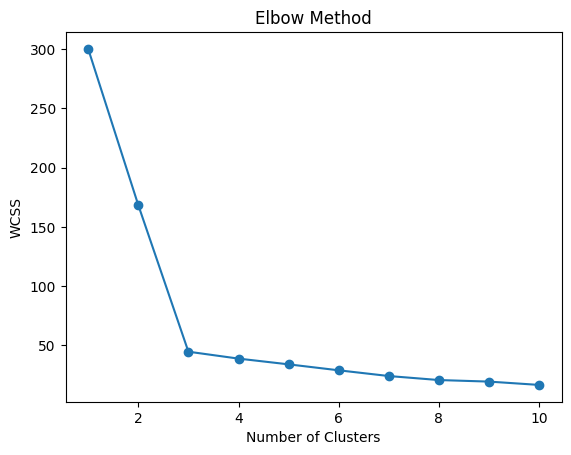

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
%matplotlib inline

wcss = []

for i in range(1, 11):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=i, random_state=42))
    ])
    pipeline.fit(data)
    wcss.append(pipeline["kmeans"].inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [18]:
X = data.iloc[:,:].values
km = KMeans(n_clusters=3)
y_means = km.fit_predict(X)
y_means

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [19]:
X[y_means == 0]

array([[ 3.07753038,  0.63181217],
       [ 2.82755505,  1.50541082],
       [ 3.47400547, -1.66027074],
       [ 2.92600216,  0.72389137],
       [ 5.03772712,  2.83563557],
       [ 3.27598488,  1.16040466],
       [ 2.67300941,  1.15094259],
       [ 3.72422079,  0.23580778],
       [ 3.4488506 , -0.74840508],
       [ 3.42774274, -0.32417924],
       [ 0.02611098,  0.61196462],
       [ 1.44845407, -0.48839622],
       [ 4.05426968,  0.32315598],
       [ 2.26858326, -0.63183456],
       [ 3.98388723, -0.12425651],
       [ 3.70263999, -0.42883913],
       [ 2.55259196, -0.37680845],
       [ 1.74023364,  2.06161754],
       [ 4.68659277, -1.45074464],
       [ 4.05174377,  0.02650859],
       [ 3.54131823, -0.68644962],
       [ 3.1563902 ,  0.93871313],
       [ 3.71818844, -1.14130276],
       [ 2.95468937, -0.78109274],
       [ 1.88861795,  1.6236479 ],
       [ 4.55718338, -0.39616965],
       [ 2.00917324,  2.29680349],
       [ 3.8706424 , -1.48315543],
       [ 1.57108538,

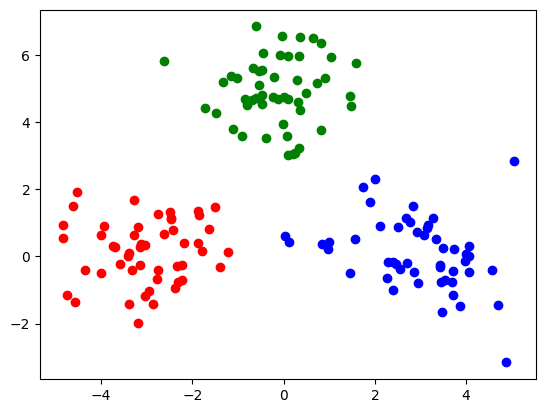

In [20]:
from turtle import color


plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color="blue")
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color="red")
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color="green")

## Add Scaling + Pipeline

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

pipeline.fit(data)

labels = pipeline["kmeans"].labels_

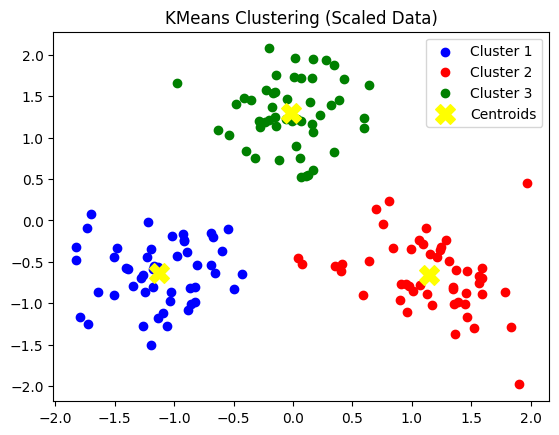

In [22]:
import matplotlib.pyplot as plt

X_scaled = pipeline["scaler"].transform(data)
centroids = pipeline["kmeans"].cluster_centers_

plt.scatter(X_scaled[labels == 0, 0], X_scaled[labels == 0, 1], c='blue', label='Cluster 1')
plt.scatter(X_scaled[labels == 1, 0], X_scaled[labels == 1, 1], c='red', label='Cluster 2')
plt.scatter(X_scaled[labels == 2, 0], X_scaled[labels == 2, 1], c='green', label='Cluster 3')

plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='yellow', marker='X', label='Centroids')

plt.legend()
plt.title("KMeans Clustering (Scaled Data)")
plt.show()